<a href="https://githubtocolab.com/BorjaRequena/Machine-Learning-Course/blob/master/nbs/course/classical_ml/ml_recipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [1]:
#| hide
import numpy as np
import matplotlib.pyplot as plt

# Main ingredients

In the [introduction to machine learning](https://borjarequena.github.io/Machine-Learning-Course/course/introduction.html) chapter of these lectures, we introduce the fundamental ingredients of any machine learning application: a task to solve, data, a performance measure, and a model to encode the algorithm.
Here, we will initially focus on the first three, as we will work with a couple of different models.

## The task

The task we will address in this illustrative example is determining whether a breast tumor is benign or malignant based on measurements of cell nuclei properties from a fine needle aspiration biopsy.

## The data

We will use the [breast cancer Winsconsin diagnostic dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) provided the University of Winsconsin and first introduced with [this paper](https://www.semanticscholar.org/paper/Nuclear-feature-extraction-for-breast-tumor-Street-Wolberg/53f0fbb425bc14468eb3bf96b2e1d41ba8087f36).
This is a "toy dataset" with labeled samples of cell nuclei attributes belonging to benign or malignant tumors.
The first thing we will do is to have a look at the data to understand it better.



In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target  # Get the design matrix and the target vector
print(data.DESCR[:1000])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In the description we see that we have data of 569 tissue samples and 10 different attributes of the nuclei to look at.
Then, for each tissue sample, they report the mean value, standard error and mean of the three "worst" values across all the cells in the sample.
Therefore, this results in 30 ($10\times 3$) descriptors for each sample.


In [3]:
label, label_counts = np.unique(data.target_names[y], return_counts=True)
balance = y.mean()
feature_ranges = X.max(axis=0) - X.min(axis=0)
print(f"The design matrix has shape {X.shape} and the target vector has shape {y.shape}.")
print(f"There are {label_counts[0]} {label[0]} and {label_counts[1]} {label[1]} samples (class balance {balance:.2f}/{1-balance:.2f}).")
print(f"The features have a maximum range of {feature_ranges.max():.2e} and a minimum range of {feature_ranges.min():.2e}.")

The design matrix has shape (569, 30) and the target vector has shape (569,).
There are 357 benign and 212 malignant samples (class balance 0.63/0.37).
The features have a maximum range of 4.07e+03 and a minimum range of 2.89e-02.


The dataset is slightly imbalanced and the features have very different ranges.
This means that we will have to choose the performance metrics carefully and scale the data of every column separately to bring them to a common range.

::: {.callout-warning}

We need to pay special attention to prevent **data leakage**.
Whenever we perform any data transformation that depends on more than each sample by itself, such as scaling (subtract mean and divide by std) or any dimensionality reduction, we must only do those after properly splitting the data into the different train, validation and test sets.
Otherwise, the information can leak between data sets and affect the integrity of our experiments.

In the scikit learn library, the best practice is to put the data processing in a [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

:::

As in any other machine learning task, we will split the data into a training and test sets.
The former will be used to train our models and potentially tune their hyper-parameters (with a further validation split), whereas the latter will be held out from any model tweaking process and will **only be used to report the final performance over unseen data**. 

In [4]:
from sklearn.model_selection import train_test_split

# Set a random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

## Performance measure

Choosing the right performance measure for the task is crucial for every specific application.
There is no single catch-all metric that can capture the nuances of each application scenario, despite the nature of the task being the same, e. g., a classification task.
For this specific example of diagnosing cancer we may want to minimize the risk of a malignant sample being misclassified as a benign one (false negative), as this could result in a patient not getting treament when needed.
Conversely, we may not be too concerned if we occasionally label a benign sample as malignant (false positive), since this will only imply some follow-up tests and it's better to be safe than sorry.

These requirements mean that we are quite concerned about the recall (or sensitivity), which will measure the fraction of actual malignant cases that are correctly detected, defined as $\text{R} = \frac{\text{TP}}{\text{TP + FN}}$.
A high recall will indicate fewer dangerous false negatives.
Nevertheless, a dumb model that always predicts the malignant label would maximize the recall, since all the malignant cases would be captured, but it would be useless in practice.
For this reason, we should also track the precision (or specificity), which measures how many predicted malignant cases are actually trully malignant, defined as $\text{P} = \frac{\text{TP}}{\text{TP + FP}}$.

To this end, we can plot the precision-recall curve, as well as to compute the ROC curve (true positive vs false positive rate), and the $F_\beta$ score.
The $F_\beta=(1 + \beta^2)\frac{\text{P} \cdot \text{R}}{\beta^2\text{P} + \text{R}}$ score combines precision and recall with $\beta=1$ weighting them equally, $\beta>1$ favouring recall, and $0<\beta<=1$ favouring precision.


In [5]:
from sklearn.metrics import accuracy_score, average_precision_score, fbeta_score, precision_recall_curve, roc_curve, roc_auc_score

def evaluate_metrics(y_true, y_pred):
    "Evaluate all the metrics of interest for our classification task."
    acc = accuracy_score(y_true, y_pred)
    fbeta = fbeta_score(y_true, y_pred, beta=2)  # F2 score emphasizing recall
    return acc, fbeta

def plot_roc_pr(y_true, y_pred, title_prefix="Model"):
    _, axes = plt.subplots(1, 2, figsize=(10, 4))
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    axes[0].plot(fpr, tpr, label="ROC")
    axes[0].plot([0,1],[0,1], linestyle="--")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title_prefix} — ROC curve (AUC = {roc_auc_score(y_true, y_pred):.3f})")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    baseline = np.mean(y_true)
    ap = average_precision_score(y_true, y_pred)
    axes[1].plot(recall, precision, label="PR")
    axes[1].hlines(baseline, 0, 1, linestyles="--", label=f"Baseline prevalence={baseline:.2f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} — Precision-Recall curve (AP = {ap:.3f})")
    axes[1].legend(loc="center left")
    axes[1].grid(alpha=0.3)

# Train a baseline

Now that we have set up the full machine learning task, the first thing we'll do is to **train a baseline**.
This will serve as a reference point to know if more complex approaches bring any significant value, and it will give us a sense of the difficulty of the task.
Additionally, training a simple model can provide us with plenty of insights about the nature of the problem and the data, such as indicating which features are more informative, or which classes are the hardest to identify.
Finally, if we are lucky, the simple baseline model may turn out to be sufficient for our needs!

::: {.callout-tip}

If your big fancy model is underperforming the baseline, there's probably a bug hidden somewhere!

:::

The most basic baselines are those that follow simple strategies, such as predicting the majority class or the mean, or even doing random predictions.
Given that we have an imbalanced dataset we will always predict the majority class, which will already guarantee an accuracy of 63%!

Let's start by defining our model.

In [6]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

In order to evaluate our models and tweak their hyper-parameters, we would typically split the training set into a validation set.
However, given that we do not have too many samples, we will resort to evaluating our model through [cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)).
This consists on doing several different train/validation splits of the data, and training and evaluating the model for each split.
At the end, we report the average validation metrics to estimate the model performance on unseen data.

In [7]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # Stratified preserves the class balance
baseline_scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"Baseline CV ROC AUC: {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")

Baseline CV ROC AUC: 0.500 ± 0.000


We have our first baseline to beat!
We are a bit restricted by the metrics that we can compute in the cross-validation, but the area under the ROC curve will work as an indicator.

# Improve over the baseline

The next natural step is to try to improve over the baseline.
Machine learning is a rather experimental field where we explore and test multiple ideas until we find the right one.
Typically, we move from simpler to more complex approaches taking informed decisions based on the results that we obtain throughout the process.

In this case, we will start off with two simple algorithms: a logistic regression and a k-nearest neighbour classifier.
As hinted above, will set them up in a pipeline that will perform the data scaling before fitting the model.
This will prevent data leakage between data splits when we evaluate the models in our cross-validation.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=RANDOM_STATE))
])

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

lr_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring="roc_auc")
knn_scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"LogReg CV ROC AUC: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"kNN CV ROC AUC: {knn_scores.mean():.3f} ± {knn_scores.std():.3f}")

LogReg CV ROC AUC: 0.996 ± 0.005
kNN CV ROC AUC: 0.988 ± 0.008


Woo!
This is a huge improvement with respect to the baseline.

## Hyper-parameter tuning

While we have obtained very good results already, we can try to squeeze out some addiitonal performance from both algorithms by palying with their hyper-parameters.
We will perform this optimization through a grid search, evaluating the models for multiple values of their parameters, and keeping the best at the end.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {"clf__C": np.logspace(-3, 3, 7)}  # Regularization parameter for Logistic Regression
param_grid_knn = {"clf__n_neighbors": list(range(1, 31, 2))}  # Number of neighbors for k-NN

# Perform a cross-validated grid search for each model
gs_lr = GridSearchCV(lr, param_grid_lr, cv=cv, scoring="roc_auc", n_jobs=-1)
gs_knn = GridSearchCV(knn, param_grid_knn, cv=cv, scoring="roc_auc", n_jobs=-1)

gs_lr.fit(X_train, y_train)
gs_knn.fit(X_train, y_train)

# Keep the best models
best_lr = gs_lr.best_estimator_
best_knn = gs_knn.best_estimator_

print(f"LogReg best CV ROC AUC: {gs_lr.best_score_:.3f} with params {gs_lr.best_params_}")
print(f"kNN best CV ROC AUC: {gs_knn.best_score_:.3f} with params {gs_knn.best_params_}")

LogReg best CV ROC AUC: 0.996 with params {'clf__C': np.float64(1.0)}
kNN best CV ROC AUC: 0.992 with params {'clf__n_neighbors': 13}


# Report performance on test set

The last step in our machine learning recipe is to evaluate the best model that we have found in the test set.
This will be the best indicator of the generalization capabilities of the resulting models we have access to.

LogReg — Test metrics
Accuracy: 0.982
F2 score: 0.986
kNN — Test metrics
Accuracy: 0.974
F2 score: 0.992


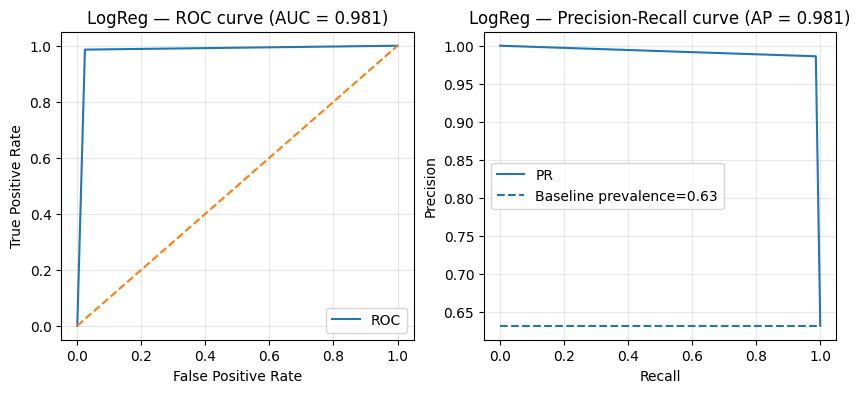

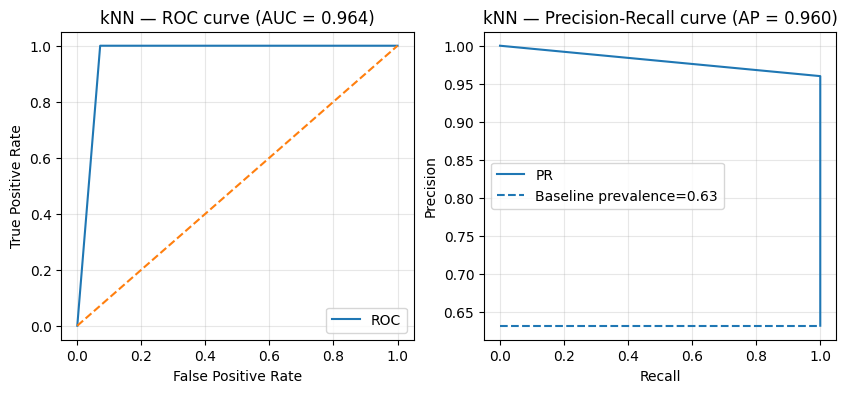

In [12]:
models = [
    ("LogReg", best_lr),
    ("kNN", best_knn)
]

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc, fbeta = evaluate_metrics(y_test, y_pred)
    print(f"{name} — Test metrics")
    print(f"Accuracy: {acc:.3f}")
    print(f"F2 score: {fbeta:.3f}")
    plot_roc_pr(y_test, y_pred, title_prefix=name)

While the logistic regression presents better results across the board, the k-nearest neighbours classifier has an edge in terms of $F_2$ score.
Which model would you choose to bring to the hospital?